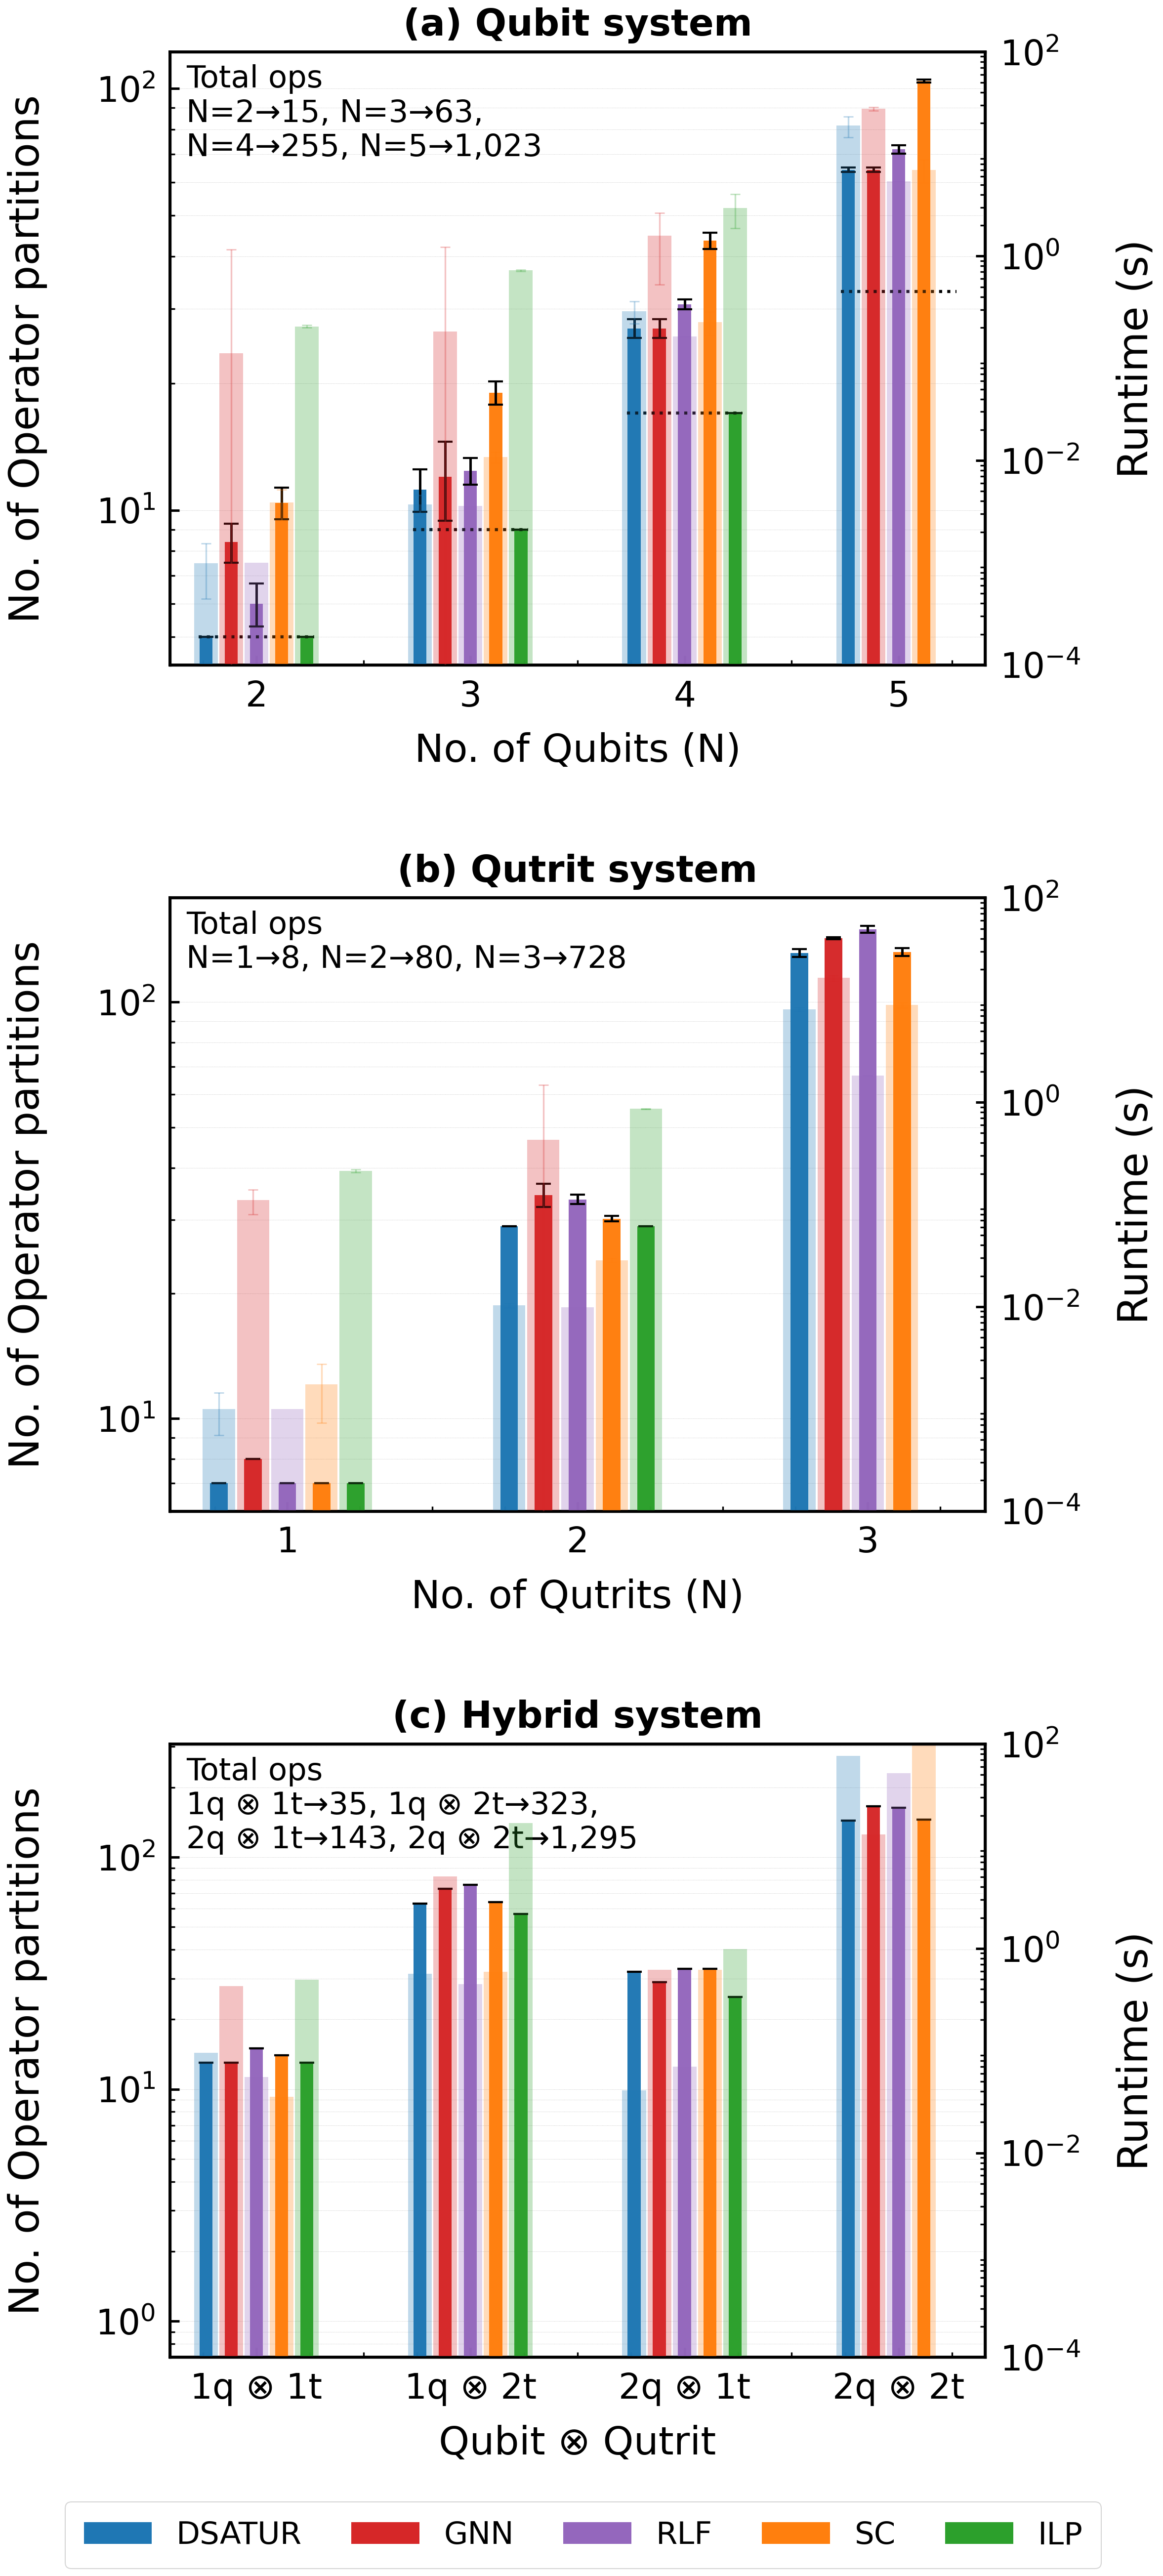

In [14]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Patch
from matplotlib.ticker import (
    LogFormatterMathtext, LogLocator, FixedLocator
)

%matplotlib inline

CSV_QS = "qubits_qutrits_full_basis_runs.csv"
CSV_HT = "hybrid_full_basis_runs.csv"

def read_csv_auto(path):
    df = pd.read_csv(path)
    if len(df.columns) == 1 and ";" in str(df.columns[0]):
        df = pd.read_csv(path, sep=";")
    df.columns = [str(c).strip() for c in df.columns]
    return df

FONT = 36
INFO_FONT_QS  = max(FONT - 6, 18)
INFO_FONT_HET = max(FONT - 6, 18)

plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "figure.dpi": 150, "savefig.dpi": 600,
    "font.size":   FONT,
    "axes.labelsize": FONT + 2,
    "axes.titlesize": FONT + 4,
    "xtick.labelsize": FONT - 2,
    "ytick.labelsize": FONT - 2,
    "legend.fontsize": FONT - 6,
    "axes.linewidth": 2.8,
    "xtick.major.width": 2.4, "ytick.major.width": 2.4,
    "xtick.minor.width": 1.6, "ytick.minor.width": 1.6,
    "xtick.major.size": 9,    "ytick.major.size": 9,
    "xtick.minor.size": 5,    "ytick.minor.size": 5,
    "axes.grid": False,
})

df_qs = read_csv_auto(CSV_QS)
has_row_type = "row_type" in df_qs.columns

for col in ["d", "N", "total_ops", "colors", "times", "colors_std", "times_std", "seed", "n_seeds"]:
    if col in df_qs.columns:
        df_qs[col] = pd.to_numeric(df_qs[col], errors="coerce")

df_qs["system"] = df_qs["system"].astype(str)
df_qs["method"] = df_qs["method"].astype(str)

if "d" in df_qs.columns:
    df_qs["d"] = df_qs["d"].astype("Int64")
if "N" in df_qs.columns:
    df_qs["N"] = df_qs["N"].astype("Int64")

if has_row_type:
    df_qs_sum = df_qs[df_qs["row_type"] == "summary"].copy()
    df_qs_sum["colors_std"] = df_qs_sum.get("colors_std", 0.0).fillna(0.0)
    df_qs_sum["times_std"]  = df_qs_sum.get("times_std", 0.0).fillna(0.0)

    for col in ["d", "N", "total_ops", "n_seeds"]:
        if col in df_qs_sum.columns:
            try:
                df_qs_sum[col] = df_qs_sum[col].astype(int)
            except Exception:
                pass
else:
    df_qs_sum = (
        df_qs.groupby(["system", "d", "N", "method"], as_index=False)
        .agg(
            colors=("colors", "mean"),
            colors_std=("colors", "std"),
            times=("times", "mean"),
            times_std=("times", "std"),
            total_ops=("total_ops", "max"),
        )
    )

df_qs_sum = df_qs_sum.dropna(subset=["system", "d", "N", "method", "colors"])
df_qs_sum["d"] = df_qs_sum["d"].astype(int)
df_qs_sum["N"] = df_qs_sum["N"].astype(int)

if "total_ops" in df_qs_sum.columns and df_qs_sum["total_ops"].notna().any():
    df_qs_sum["total_ops"] = df_qs_sum["total_ops"].astype(int)

df_ht = read_csv_auto(CSV_HT)

if "row_type" in df_ht.columns and (df_ht["row_type"] == "raw").any():
    df_ht = df_ht[df_ht["row_type"] == "raw"].copy()

for c in ["n_qubits", "n_qutrits", "M_used", "total_ops", "seed", "colors", "times", "times_std"]:
    if c in df_ht.columns:
        df_ht[c] = pd.to_numeric(df_ht[c], errors="coerce")

df_ht = df_ht.dropna(subset=["n_qubits", "n_qutrits", "method", "colors"])

if not df_ht.empty:
    df_ht["n_qubits"]  = df_ht["n_qubits"].astype(int)
    df_ht["n_qutrits"] = df_ht["n_qutrits"].astype(int)

    if "M_used" in df_ht:
        df_ht["M_used"] = df_ht["M_used"].astype(int, errors="ignore")
    if "total_ops" in df_ht:
        df_ht["total_ops"] = df_ht["total_ops"].astype(int, errors="ignore")

    df_ht["method"] = df_ht["method"].astype(str)

methods_qs = sorted(df_qs_sum["method"].unique().tolist())
methods_ht = sorted(df_ht["method"].unique().tolist()) if not df_ht.empty else []
methods_all = sorted(set(methods_qs) | set(methods_ht))

palette = [
    "#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e",
    "#8c564b", "#17becf", "#e377c2", "#7f7f7f", "#bcbd22",
]

style = {m: dict(color=palette[i % len(palette)]) for i, m in enumerate(sorted(methods_all))}

def ilp_last(method_list):
    return [m for m in method_list if m.lower() != "ilp"] + [
        m for m in method_list if m.lower() == "ilp"
    ]

def fmt_int(x):
    try:
        return f"{int(x):,}"
    except:
        return str(x)

def total_ops_for(d_val, Ns, sub_df=None):
    if sub_df is not None and "total_ops" in sub_df.columns and sub_df["total_ops"].notna().any():
        m = sub_df.groupby("N", as_index=False)["total_ops"].max()
        m = dict(zip(m["N"].astype(int), m["total_ops"].astype(int)))
        return [int(m.get(n, (d_val * d_val) ** n - 1)) for n in Ns]

    return [(d_val * d_val) ** n - 1 for n in Ns]

def make_info_text_qubits(Ns, totals):
    entries = [(int(n), f"N={int(n)}→{fmt_int(t)}") for n, t in zip(Ns, totals)]
    line1_items = [s for n, s in entries if n < 4]
    line2_items = [s for n, s in entries if n >= 4]

    line1 = ", ".join(line1_items)
    line2 = ", ".join(line2_items)

    txt = "Total ops\n"

    if line2:
        txt += line1 + ("," if line1 else "") + "\n" + line2
    else:
        txt += line1

    return txt

def make_info_text_generic(Ns, totals):
    items = [f"N={int(n)}→{fmt_int(t)}" for n, t in zip(Ns, totals)]

    if len(items) > 6:
        half = (len(items) + 1) // 2
        line1 = ", ".join(items[:half])
        line2 = ", ".join(items[half:])
        return "Total ops\n" + line1 + ("," if line2 else "") + "\n" + line2

    return "Total ops\n" + ", ".join(items)

def make_info_text_hetero_two_lines(pairs, totals):
    items = [
        f"{nq}q ⊗ {nt}t→{fmt_int(tot) if tot is not None else 'n/a'}"
        for (nq, nt), tot in zip(pairs, totals)
    ]

    if len(items) <= 1:
        return "Total ops\n" + (items[0] if items else "")

    half = (len(items) + 1) // 2
    line1 = ", ".join(items[:half])
    line2 = ", ".join(items[half:])

    return "Total ops\n" + line1 + "," + "\n" + line2

RUNTIME_YMIN = 1e-4
RUNTIME_YMAX = 1e2
RUNTIME_TICKS = [1e-4, 1e-2, 1e0, 1e2]
RUNTIME_FMT = LogFormatterMathtext(base=10)

LABEL_OFFSETS = {
    "left": -0.15,
    "right": 1.16,
}

TICK_PAD = 14
XLABEL_PAD = 18

GRID_LW   = 0.45
GRID_ALPH = 0.75
GRID_COL  = "0.65"

def draw_uniform_log_grid_left(ax):
    ax.set_axisbelow(False)
    ax.grid(False)

    if not isinstance(ax.yaxis.get_major_locator(), LogLocator):
        ax.yaxis.set_major_locator(LogLocator(base=10.0))

    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))

    ax.grid(
        True, which="major", axis="y",
        linestyle=":", linewidth=GRID_LW,
        alpha=GRID_ALPH, color=GRID_COL, zorder=10
    )

    ax.grid(
        True, which="minor", axis="y",
        linestyle=":", linewidth=GRID_LW,
        alpha=GRID_ALPH, color=GRID_COL, zorder=10
    )

def configure_right_log_axis(ax2, show_label=True):
    ax2.set_yscale("log", base=10)
    ax2.set_ylim(RUNTIME_YMIN, RUNTIME_YMAX)

    ax2.yaxis.set_major_locator(FixedLocator(RUNTIME_TICKS))
    ax2.yaxis.set_major_formatter(RUNTIME_FMT)
    ax2.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))

    ax2.tick_params(
        axis="y", which="both",
        right=True, labelright=True,
        pad=TICK_PAD, labelsize=FONT - 2
    )

    for sp in ax2.spines.values():
        sp.set_linewidth(2.6)

    ax2.grid(False)

    if show_label:
        ax2.set_ylabel("Runtime (s)")
        ax2.yaxis.set_label_coords(LABEL_OFFSETS["right"], 0.5)
        ax2.yaxis.label.set_fontsize(FONT + 4)
    else:
        ax2.set_ylabel(None)

def _safe_pos(vals):
    v = np.array(vals, dtype=float)
    v = np.where(np.isfinite(v) & (v > 0), v, np.nan)
    return v

GROUP_SPACING = 2.8
WIDTH_PART_MAX = 0.22
GAP_PART_MIN   = 0.16
GAP_PART_REL   = 0.64
TIME_W_CAP     = 1.08

def _calc_offsets_and_widths(M):
    width_part = min(WIDTH_PART_MAX, 0.85 / max(1, M))
    gap_part   = max(GAP_PART_MIN, GAP_PART_REL * width_part)
    delta      = width_part + gap_part
    eps = 0.06
    width_time = min(delta * (1.0 - eps), TIME_W_CAP)
    offsets = (np.arange(M) - (M - 1) / 2.0) * delta

    return width_part, gap_part, offsets, width_time, delta

def _style_axes_common(ax, add_left_label: bool, left_label_text: str):
    ax.set_yscale("log")

    for sp in ax.spines.values():
        sp.set_linewidth(2.8)

    ax.tick_params(axis="x", which="both", pad=TICK_PAD)
    ax.tick_params(axis="y", which="both", pad=TICK_PAD)

    if add_left_label:
        ax.set_ylabel(left_label_text)
        ax.yaxis.set_label_coords(LABEL_OFFSETS["left"], 0.5)
        ax.yaxis.label.set_fontsize(FONT + 4)
    else:
        ax.set_ylabel(None)

def plot_qs_panel(
    ax,
    sub_sum,
    title,
    x_label,
    add_y_label=False,
    draw_mub_segments=False,
    show_time_ylabel=True
):
    if sub_sum.empty:
        ax.set_title(title, pad=16, fontweight="bold", fontsize=FONT + 2)
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        return

    methods = ilp_last(sorted(sub_sum["method"].unique().tolist()))
    Ns = sorted(sub_sum["N"].unique().astype(int).tolist())
    x = np.arange(len(Ns), dtype=float) * GROUP_SPACING

    M = len(methods)
    width_part, gap_part, offsets, width_time, delta = _calc_offsets_and_widths(M)

    per_m_colors, per_m_times = {}, {}

    for m in methods:
        g = (
            sub_sum[sub_sum["method"] == m]
            .groupby("N", as_index=False)
            .agg(
                mu_c=("colors", "mean"),
                sd_c=("colors_std", "mean"),
                mu_t=("times", "mean"),
                sd_t=("times_std", "mean"),
            )
            .sort_values("N")
        )

        g["N"] = g["N"].astype(int)
        gN = set(g["N"].tolist())

        mu_c = np.array([
            float(g.loc[g["N"] == n, "mu_c"].iloc[0]) if n in gN else np.nan
            for n in Ns
        ], dtype=float)

        sd_c = np.array([
            float(g.loc[g["N"] == n, "sd_c"].iloc[0])
            if n in gN and pd.notna(g.loc[g["N"] == n, "sd_c"].iloc[0])
            else 0.0
            for n in Ns
        ], dtype=float)

        mu_t = np.array([
            float(g.loc[g["N"] == n, "mu_t"].iloc[0])
            if n in gN and pd.notna(g.loc[g["N"] == n, "mu_t"].iloc[0])
            else np.nan
            for n in Ns
        ], dtype=float)

        sd_t = np.array([
            float(g.loc[g["N"] == n, "sd_t"].iloc[0])
            if n in gN and pd.notna(g.loc[g["N"] == n, "sd_t"].iloc[0])
            else 0.0
            for n in Ns
        ], dtype=float)

        per_m_colors[m] = (mu_c, sd_c)
        per_m_times[m] = (_safe_pos(mu_t), _safe_pos(sd_t))

    ax2 = ax.twinx()

    for i, m in enumerate(methods):
        mu_t, sd_t = per_m_times[m]
        col = style.get(m, {"color": "C0"})["color"]
        pos = x + offsets[i]

        ax2.bar(
            pos, mu_t,
            width=width_time,
            color=col,
            edgecolor="none",
            alpha=0.28,
            zorder=2
        )

        ax2.errorbar(
            pos, mu_t,
            yerr=sd_t,
            fmt="none",
            ecolor=col,
            elinewidth=1.6,
            capsize=5.0,
            capthick=1.4,
            alpha=0.28,
            zorder=3
        )

    configure_right_log_axis(ax2, show_label=True)

    ymax = 0.0

    for i, m in enumerate(methods):
        mu, sd = per_m_colors[m]
        col = style.get(m, {"color": "C0"})["color"]
        pos = x + offsets[i]

        ax.bar(
            pos, mu,
            width=width_part,
            color=col,
            edgecolor="none",
            linewidth=0.0,
            alpha=0.98,
            zorder=4,
            label=m
        )

        ax.errorbar(
            pos, mu,
            yerr=sd,
            fmt="none",
            ecolor="black",
            elinewidth=2.4,
            capsize=7.0,
            capthick=2.0,
            zorder=5
        )

        val_max = np.nanmax(mu + np.nan_to_num(sd))
        if np.isfinite(val_max):
            ymax = max(ymax, float(val_max))

    min_off_time = float(np.min(offsets) - width_time * 0.56)
    max_off_time = float(np.max(offsets) + width_time * 0.56)

    ax.set_xlim(
        x[0] + min_off_time - 0.30,
        x[-1] + max_off_time + 0.30
    )

    if draw_mub_segments:
        group_lefts = x + (np.min(offsets) - width_part * 0.55)
        group_rights = x + (np.max(offsets) + width_part * 0.55)

        for n, xl, xr in zip(Ns, group_lefts, group_rights):
            mub = (2 ** int(n)) + 1
            ax.hlines(
                y=mub,
                xmin=xl,
                xmax=xr,
                linestyles=":",
                linewidth=3.0,
                colors="black",
                zorder=6
            )

    ax.set_title(title, pad=16, fontweight="bold", fontsize=FONT)
    ax.set_xticks(x, [str(n) for n in Ns])
    ax.set_xlabel(x_label, labelpad=XLABEL_PAD)

    _style_axes_common(ax, add_y_label, "No. of Operator partitions")
    draw_uniform_log_grid_left(ax)

    d_val = int(sub_sum["d"].iloc[0])
    totals = total_ops_for(
        d_val,
        Ns,
        sub_sum if "total_ops" in sub_sum.columns else None
    )

    ax.text(
        0.02, 0.98,
        make_info_text_qubits(Ns, totals) if d_val == 2 else make_info_text_generic(Ns, totals),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=INFO_FONT_QS,
        bbox=dict(
            boxstyle="round,pad=0.42",
            facecolor=(1, 1, 1, 0.0),
            edgecolor="none"
        ),
        zorder=7
    )

def plot_hetero_panel(ax, df_ht_raw, title, add_y_label=False):
    if df_ht_raw.empty:
        ax.set_title(title, pad=16, fontweight="bold", fontsize=FONT + 2)
        ax.text(0.5, 0.5, "No heterogeneous data", ha="center", va="center")
        ax.axis("off")
        return

    methods = ilp_last(sorted(df_ht_raw["method"].unique().tolist()))

    cases = sorted(
        df_ht_raw[["n_qubits", "n_qutrits"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )

    x = np.arange(len(cases), dtype=float) * GROUP_SPACING

    M = len(methods)
    width_part, gap_part, offsets, width_time, delta = _calc_offsets_and_widths(M)

    stats_c = {(nq, nt): {} for (nq, nt) in cases}
    stats_t = {(nq, nt): {} for (nq, nt) in cases}

    for (nq, nt) in cases:
        sub = df_ht_raw[
            (df_ht_raw["n_qubits"] == nq)
            & (df_ht_raw["n_qutrits"] == nt)
        ]

        for m in methods:
            s_m = sub.loc[sub["method"] == m]

            vals_c = s_m["colors"].to_numpy(float)
            vals_c = vals_c[np.isfinite(vals_c) & (vals_c > 0)]

            mu_c = float(np.mean(vals_c)) if vals_c.size else np.nan
            sd_c = float(np.std(vals_c)) if vals_c.size else 0.0

            stats_c[(nq, nt)][m] = (mu_c, sd_c)

            if "times" in s_m.columns:
                vals_t = s_m["times"].to_numpy(float)
                vals_t = vals_t[np.isfinite(vals_t) & (vals_t > 0)]

                mu_t = float(np.mean(vals_t)) if vals_t.size else np.nan
                sd_t = float(np.std(vals_t)) if vals_t.size else 0.0
            else:
                mu_t, sd_t = np.nan, 0.0

            stats_t[(nq, nt)][m] = (_safe_pos(mu_t), _safe_pos(sd_t))

    ax2 = ax.twinx()

    for i, m in enumerate(methods):
        col = style.get(m, {"color": "C0"})["color"]
        mu_t = np.array([stats_t[c][m][0] for c in cases], dtype=float)
        sd_t = np.array([stats_t[c][m][1] for c in cases], dtype=float)
        pos = x + offsets[i]

        ax2.bar(
            pos, mu_t,
            width=width_time,
            color=col,
            edgecolor="none",
            alpha=0.28,
            zorder=2
        )

        ax2.errorbar(
            pos, mu_t,
            yerr=sd_t,
            fmt="none",
            ecolor=col,
            elinewidth=1.6,
            capsize=5.0,
            capthick=1.4,
            alpha=0.28,
            zorder=3
        )

    configure_right_log_axis(ax2, show_label=True)

    ymax = 0.0

    for i, m in enumerate(methods):
        col = style.get(m, {"color": "C0"})["color"]

        mu = np.array([stats_c[c][m][0] for c in cases], dtype=float)
        sd = np.array([stats_c[c][m][1] for c in cases], dtype=float)
        pos = x + offsets[i]

        ax.bar(
            pos, mu,
            width=width_part,
            color=col,
            edgecolor="none",
            linewidth=0.0,
            alpha=0.98,
            zorder=4,
            label=m
        )

        ax.errorbar(
            pos, mu,
            yerr=sd,
            fmt="none",
            ecolor="black",
            elinewidth=2.4,
            capsize=7.0,
            capthick=2.0,
            zorder=5
        )

        val_max = np.nanmax(mu + np.nan_to_num(sd))
        if np.isfinite(val_max):
            ymax = max(ymax, float(val_max))

    min_off_time = float(np.min(offsets) - width_time * 0.56)
    max_off_time = float(np.max(offsets) + width_time * 0.56)

    ax.set_xlim(
        x[0] + min_off_time - 0.30,
        x[-1] + max_off_time + 0.30
    )

    ax.set_title(title, pad=16, fontweight="bold", fontsize=FONT)
    ax.set_yscale("log")
    ax.set_ylim(max(1e-6, 0.7), ymax * 1.85 if ymax > 0 else 2.0)

    ax.set_xticks(x, [f"{nq}q ⊗ {nt}t" for (nq, nt) in cases])
    ax.set_xlabel("Qubit ⊗ Qutrit", labelpad=XLABEL_PAD)

    for sp in ax.spines.values():
        sp.set_linewidth(2.8)

    ax.tick_params(axis="x", which="both", pad=TICK_PAD)
    ax.tick_params(axis="y", which="both", pad=TICK_PAD)

    if add_y_label:
        ax.set_ylabel("No. of Operator partitions")
        ax.yaxis.set_label_coords(LABEL_OFFSETS["left"], 0.5)
        ax.yaxis.label.set_fontsize(FONT + 4)
    else:
        ax.set_ylabel(None)

    draw_uniform_log_grid_left(ax)

    pairs = [(nq, nt) for (nq, nt) in cases]
    totals = []

    for (nq, nt) in pairs:
        sc = df_ht_raw[
            (df_ht_raw["n_qubits"] == nq)
            & (df_ht_raw["n_qutrits"] == nt)
        ]

        if "total_ops" in sc.columns and not sc["total_ops"].isna().all():
            try:
                totals.append(int(sc["total_ops"].max()))
            except Exception:
                totals.append(None)
        else:
            totals.append(None)

    ax.text(
        0.02, 0.98,
        make_info_text_hetero_two_lines(pairs, totals),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=INFO_FONT_HET,
        bbox=dict(
            boxstyle="round,pad=0.40",
            facecolor=(1, 1, 1, 0.0),
            edgecolor="none"
        ),
        zorder=7
    )

fig = plt.figure(figsize=(15.5, 34.0))
gs = fig.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=[1.0, 1.0, 1.0],
    hspace=0.38
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])

sub_qb_sum = df_qs_sum[
    (df_qs_sum["system"] == "qubit")
    & (df_qs_sum["d"] == 2)
].copy()

sub_qt_sum = df_qs_sum[
    (df_qs_sum["system"] == "qutrit")
    & (df_qs_sum["d"] == 3)
].copy()

plot_qs_panel(
    ax1,
    sub_qb_sum,
    title="(a) Qubit system",
    x_label="No. of Qubits (N)",
    add_y_label=True,
    draw_mub_segments=True,
    show_time_ylabel=True
)

plot_qs_panel(
    ax2,
    sub_qt_sum,
    title="(b) Qutrit system",
    x_label="No. of Qutrits (N)",
    add_y_label=True,
    draw_mub_segments=False,
    show_time_ylabel=True
)

plot_hetero_panel(
    ax3,
    df_ht,
    title="(c) Hybrid system",
    add_y_label=True
)

methods_in_fig = sorted(
    set(sub_qb_sum["method"].unique().tolist() if not sub_qb_sum.empty else [])
    | set(sub_qt_sum["method"].unique().tolist() if not sub_qt_sum.empty else [])
    | set(df_ht["method"].unique().tolist() if not df_ht.empty else [])
)

methods_in_fig = (
    [m for m in methods_in_fig if m.lower() != "ilp"]
    + [m for m in methods_in_fig if m.lower() == "ilp"]
)

legend_patches = [
    Patch(
        facecolor=style.get(m, {"color": "C0"})["color"],
        edgecolor="none",
        label=("SC" if m.lower().startswith("spectral") else m)
    )
    for m in methods_in_fig
]

leg = fig.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.55, -0.02),
    ncol=min(len(methods_in_fig), 6),
    frameon=True,
    fontsize=FONT - 6,
    columnspacing=1.6,
    handlelength=2.2,
    borderpad=0.6
)

leg.get_frame().set_linewidth(1.0)

plt.subplots_adjust(left=0.19, right=0.9, top=0.985, bottom=0.07)

display(fig)
plt.close(fig)

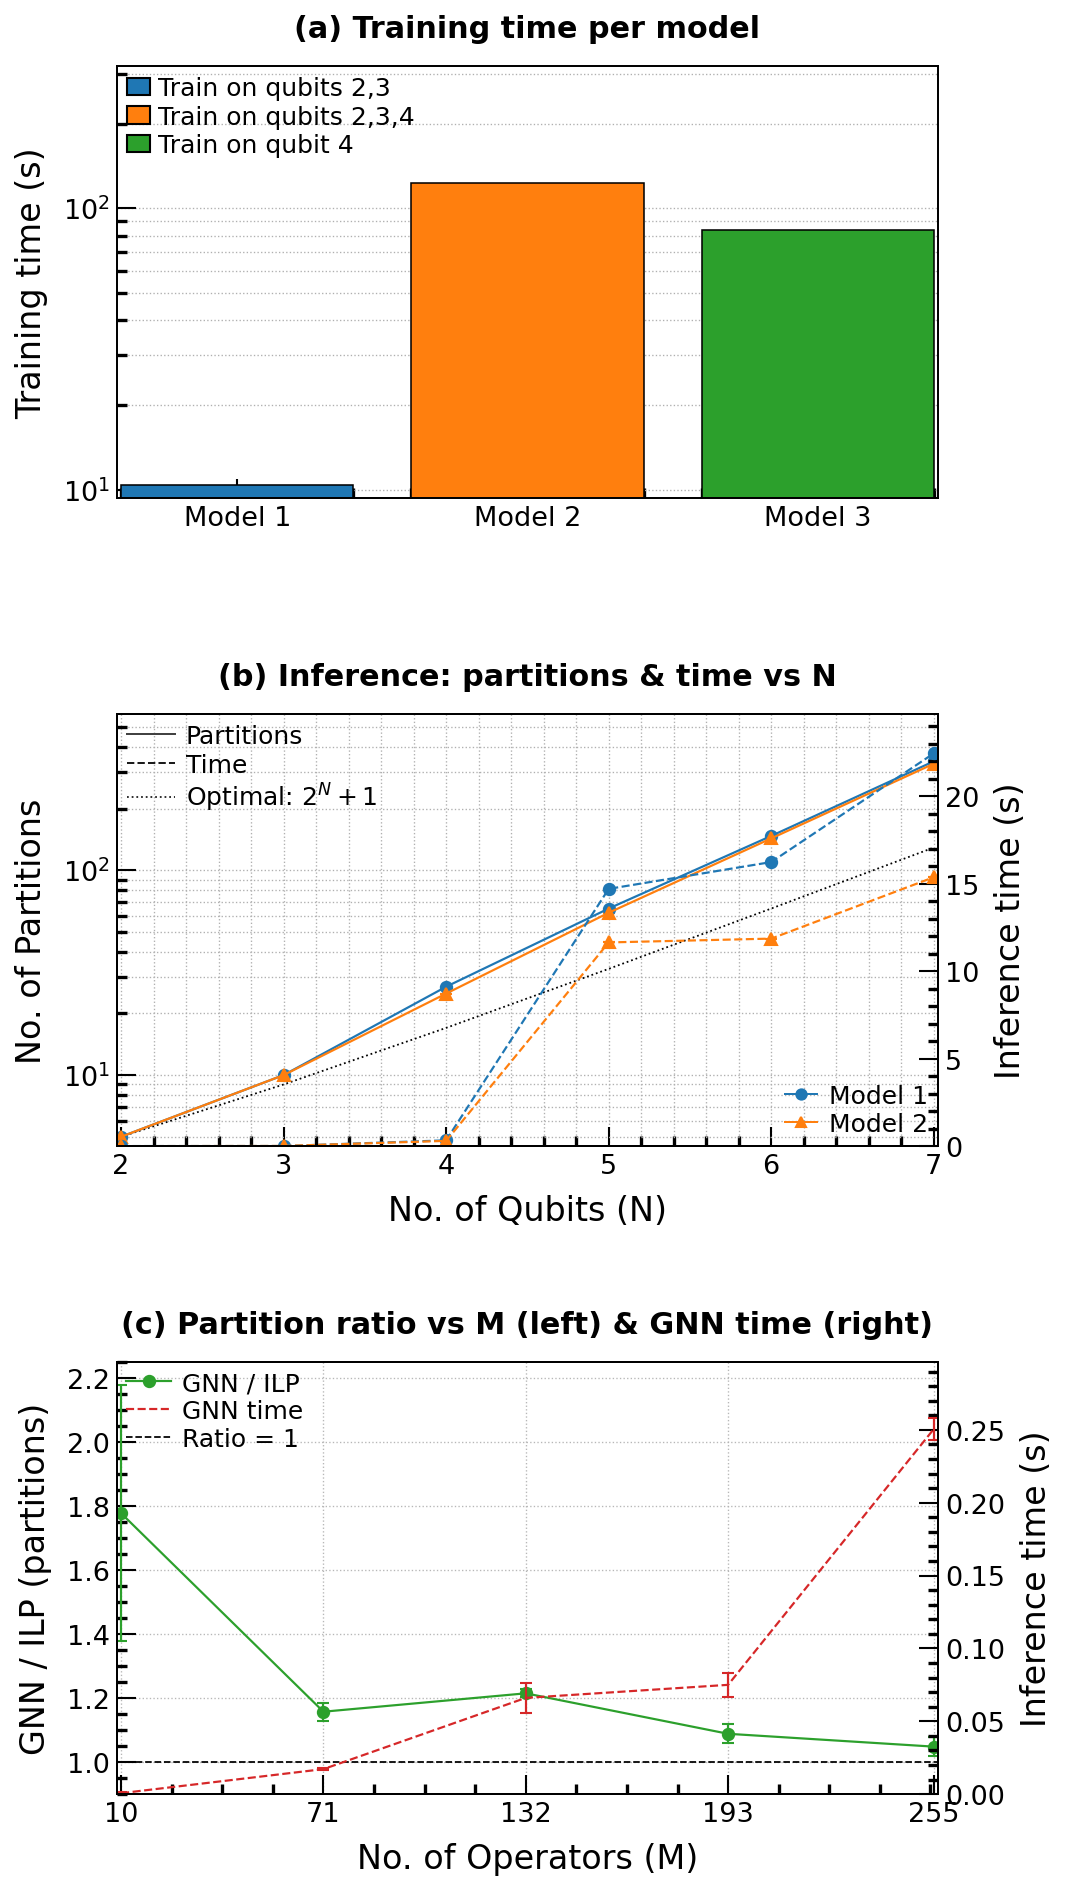

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

%matplotlib inline

plt.rcParams.update({
    "font.size": 12.5,
    "axes.titlesize": 14.5,
    "axes.labelsize": 16.0,
    "xtick.labelsize": 13.0,
    "ytick.labelsize": 13.0,
    "legend.fontsize": 12.0,
    "figure.titlesize": 14.0,
    "axes.titlepad": 5.0,
    "axes.labelpad": 7.0,
    "xtick.major.pad": 3.5,
    "ytick.major.pad": 3.5,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

LINE_W      = 1.05
LINE_W_TIME = 1.05
LINE_W_REF  = 0.85
MSIZE       = 5.4
CAPSIZE     = 2.7

if os.path.exists("gnn_multi_models_runs(1).csv"):
    CSV = "gnn_multi_models_runs(1).csv"
else:
    CSV = "gnn_multi_models_runs.csv"

df = pd.read_csv(CSV, sep=";", engine="python")
df.columns = [str(c).strip() for c in df.columns]

num_cols = [
    "train_seconds", "target_N", "target_M_used", "total_ops", "colors", "time",
    "colors_gnn", "colors_ilp", "time_gnn", "time_ilp",
    "ratio_gnn_over_ilp", "ratio_mean", "ratio_std", "ratio_stderr",
    "repeat_idx", "rng_seed", "n_repeats"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["row_type", "scenario", "trained_on", "model_path"]:
    if c in df.columns:
        df[c] = df[c].astype(str)

if "model_path" in df.columns:
    df["model_id"] = df["model_path"].apply(
        lambda s: os.path.basename(s) if isinstance(s, str) else s
    )
else:
    df["model_id"] = ""

def _box_axes(ax, lw=0.95):
    for sp in ax.spines.values():
        sp.set_linewidth(lw)
        sp.set_color("black")

def _scen_label(s: str) -> str:
    toks = [t for t in str(s).split("_") if t.isdigit()]
    if not toks:
        return s
    nums = ",".join(str(int(t)) for t in toks)
    return f"Train on qubit {nums}" if len(toks) == 1 else f"Train on qubits {nums}"

def set_sparse_xticks(ax, values, max_ticks=8, integer=True):
    vals = np.array(sorted(set(
        int(v) if integer else float(v)
        for v in values
        if np.isfinite(v)
    )))
    if vals.size == 0:
        return

    if vals.size <= max_ticks:
        ax.set_xticks(vals)
    else:
        step = int(np.ceil(vals.size / max_ticks))
        ax.set_xticks(vals[::step])

def safe_set_ylim_log(ax, data, pad_top_factor=1.8, pad_bottom_factor=0.88, floor=1e-12):
    d = np.asarray([v for v in data if np.isfinite(v) and v > 0.0])

    if d.size == 0:
        ax.set_yscale("log")
        ax.set_ylim(floor, 10.0)
        return

    lo = max(np.min(d) * pad_bottom_factor, floor)
    hi = np.max(d) * pad_top_factor

    if hi <= lo:
        hi = lo * 10.0

    ax.set_yscale("log")
    ax.set_ylim(lo, hi)

train_df     = df[df["row_type"] == "train"].copy()
targets_df   = df[(df["row_type"] == "infer") & (df["scenario"] == "targets")].copy()
subset_df    = df[df["row_type"] == "subset_ratio"].copy()
subset_stats = df[df["row_type"] == "subset_ratio_stats"].copy()

MODEL_COLORS = {
    "Model 1": "#1f77b4",
    "Model 2": "#ff7f0e",
    "Model 3": "#2ca02c",
}

MODEL_MARKERS = {
    "Model 1": "o",
    "Model 2": "^",
    "Model 3": "s",
}

train_df = train_df.sort_values(["scenario", "model_id"]).reset_index(drop=True)
trained_model_ids = train_df["model_id"].tolist()

trained_model_labels = {
    mid: f"Model {i + 1}"
    for i, mid in enumerate(trained_model_ids)
}

fig, (ax1, ax2, axC) = plt.subplots(3, 1, figsize=(7.2, 12.8))

fig.subplots_adjust(
    left=0.12,
    right=0.88,
    bottom=0.055,
    top=0.955,
    hspace=0.50
)

if train_df.empty:
    ax1.text(0.5, 0.5, "No training data", ha="center", va="center")
    ax1.axis("off")
else:
    labels = [f"Model {i + 1}" for i in range(len(train_df))]
    times  = train_df["train_seconds"].to_numpy(float)
    scen   = train_df["scenario"].tolist()

    for i, (t, lab) in enumerate(zip(times, labels)):
        ax1.bar(
            i,
            max(t, 1e-12),
            color=MODEL_COLORS.get(lab, f"C{i}"),
            edgecolor="black",
            linewidth=0.75,
            zorder=2
        )

    ax1.set_xticks(range(len(labels)))
    ax1.set_xticklabels(labels, ha="center", rotation=0)

    ax1.set_ylabel("Training time (s)")
    ax1.grid(True, axis="y", which="both", linestyle=":", linewidth=0.65, zorder=0)

    safe_set_ylim_log(
        ax1,
        times,
        pad_top_factor=2.6,
        pad_bottom_factor=0.9,
        floor=1e-12
    )

    ax1.margins(x=0.005, y=0.01)

    patches = [
        Patch(
            facecolor=MODEL_COLORS.get(labels[i], f"C{i}"),
            edgecolor="black",
            label=_scen_label(s)
        )
        for i, s in enumerate(scen)
    ]

    ax1.legend(
        handles=patches,
        loc="upper left",
        frameon=False,
        ncol=1,
        borderaxespad=0.20,
        borderpad=0.20,
        handlelength=0.9,
        handletextpad=0.35,
        labelspacing=0.18
    )

    _box_axes(ax1)

if targets_df.empty:
    ax2.text(0.5, 0.5, "No targets data", ha="center", va="center")
    ax2.axis("off")
else:
    ax2R = ax2.twinx()

    left_vals_all = []
    right_vals_all = []
    xtick_vals = set()
    handles_models_b = []

    for mid in trained_model_ids:
        sub = targets_df[targets_df["model_id"] == mid].copy()

        if sub.empty:
            continue

        model_label = trained_model_labels[mid]
        col = MODEL_COLORS.get(model_label, "C0")
        mk  = MODEL_MARKERS.get(model_label, "o")

        gg = (
            sub.groupby("target_N", as_index=False)
            .agg(
                colors_mean=("colors", "mean"),
                colors_std=("colors", "std"),
                time_mean=("time", "mean"),
                time_std=("time", "std")
            )
            .sort_values("target_N")
        )

        Ns = gg["target_N"].dropna().astype(int).to_numpy()
        colors_mean = gg["colors_mean"].to_numpy(float)
        colors_std  = gg["colors_std"].fillna(0).to_numpy(float)
        time_mean   = gg["time_mean"].to_numpy(float)
        time_std    = gg["time_std"].fillna(0).to_numpy(float)

        xtick_vals.update(Ns.tolist())
        left_vals_all.extend(colors_mean.tolist())
        right_vals_all.extend([v for v in time_mean if np.isfinite(v) and v >= 0])

        ax2.errorbar(
            Ns,
            colors_mean,
            yerr=colors_std,
            fmt=f"-{mk}",
            color=col,
            linewidth=LINE_W,
            capsize=CAPSIZE,
            markersize=MSIZE
        )

        ax2R.errorbar(
            Ns,
            time_mean,
            yerr=time_std,
            fmt=f"--{mk}",
            color=col,
            linewidth=LINE_W_TIME,
            capsize=CAPSIZE,
            markersize=MSIZE
        )

        handles_models_b.append(
            Line2D(
                [0], [0],
                color=col,
                marker=mk,
                linestyle="-",
                label=model_label,
                markersize=MSIZE - 0.5,
                linewidth=0.95
            )
        )

    all_Ns = sorted(list(xtick_vals))

    if all_Ns:
        mub = 2 ** np.array(all_Ns) + 1
        ax2.plot(
            all_Ns,
            mub,
            linestyle=":",
            linewidth=LINE_W_REF,
            color="black"
        )
        left_vals_all.extend(mub.tolist())

    safe_set_ylim_log(
        ax2,
        left_vals_all,
        pad_top_factor=1.7,
        pad_bottom_factor=0.9
    )

    if len(right_vals_all) > 0 and np.isfinite(right_vals_all).any():
        hi_r = np.nanmax(right_vals_all)
        ax2R.set_ylim(
            0,
            hi_r * 1.10 if np.isfinite(hi_r) and hi_r > 0 else 1.0
        )

    ax2.set_xlabel("No. of Qubits (N)")
    ax2.set_ylabel("No. of Partitions")
    ax2R.set_ylabel("Inference time (s)")

    set_sparse_xticks(ax2, all_Ns, max_ticks=8)

    ax2.grid(True, which="both", linestyle=":", linewidth=0.65, zorder=0)
    ax2.margins(x=0.005, y=0.01)

    _box_axes(ax2)
    _box_axes(ax2R)

    metric_handles_b = [
        Line2D([0], [0], color="0.25", linestyle="-",
               label="Partitions", linewidth=0.95),
        Line2D([0], [0], color="0.10", linestyle="--",
               label="Time", linewidth=0.95),
        Line2D([0], [0], color="0.10", linestyle=":",
               label=r"Optimal: $2^N + 1$", linewidth=0.85),
    ]

    leg_metric_b = ax2.legend(
        handles=metric_handles_b,
        loc="upper left",
        frameon=False,
        ncol=1,
        borderaxespad=0.20,
        borderpad=0.20,
        handlelength=1.9,
        handletextpad=0.45,
        labelspacing=0.18
    )

    ax2.add_artist(leg_metric_b)

    if handles_models_b:
        ax2.legend(
            handles=handles_models_b,
            loc="lower right",
            frameon=False,
            ncol=1,
            borderaxespad=0.20,
            borderpad=0.20,
            handlelength=1.3,
            handletextpad=0.45,
            labelspacing=0.18
        )

if subset_df.empty and subset_stats.empty:
    axC.text(0.5, 0.5, "No subset/ratio data", ha="center", va="center")
    axC.axis("off")
else:
    axCR = axC.twinx()

    if not subset_stats.empty and {"target_M_used", "ratio_mean", "ratio_stderr"}.issubset(subset_stats.columns):
        rss = subset_stats.sort_values("target_M_used").copy()

        Ms_ratio   = rss["target_M_used"].to_numpy(float)
        ratio_mean = rss["ratio_mean"].to_numpy(float)
        ratio_err  = rss["ratio_stderr"].fillna(0.0).to_numpy(float)

        axC.errorbar(
            Ms_ratio,
            ratio_mean,
            yerr=ratio_err,
            fmt="-o",
            color="#2ca02c",
            linewidth=LINE_W,
            capsize=CAPSIZE,
            markersize=MSIZE,
            label="GNN / ILP"
        )

        axC.set_ylim(
            0.90,
            max(2.25, np.nanmax(ratio_mean + ratio_err) + 0.05)
        )

    elif not subset_df.empty and {"target_M_used", "ratio_gnn_over_ilp"}.issubset(subset_df.columns):
        comp = (
            subset_df.groupby("target_M_used", as_index=False)
            .agg(
                ratio_mean=("ratio_gnn_over_ilp", "mean"),
                ratio_std=("ratio_gnn_over_ilp", "std"),
                n=("ratio_gnn_over_ilp", "count")
            )
            .sort_values("target_M_used")
        )

        comp["ratio_stderr"] = comp["ratio_std"] / np.sqrt(comp["n"].clip(lower=1))

        Ms_ratio   = comp["target_M_used"].to_numpy(float)
        ratio_mean = comp["ratio_mean"].to_numpy(float)
        ratio_err  = comp["ratio_stderr"].fillna(0.0).to_numpy(float)

        axC.errorbar(
            Ms_ratio,
            ratio_mean,
            yerr=ratio_err,
            fmt="-o",
            color="#2ca02c",
            linewidth=LINE_W,
            capsize=CAPSIZE,
            markersize=MSIZE,
            label="GNN / ILP"
        )

        axC.set_ylim(
            0.90,
            max(2.25, np.nanmax(ratio_mean + ratio_err) + 0.05)
        )

    else:
        raise RuntimeError("No valid ratio data found for plot (c).")

    axC.axhline(
        1.0,
        linestyle="--",
        linewidth=LINE_W_REF,
        color="black"
    )

    if not subset_df.empty and {"target_M_used", "time_gnn"}.issubset(subset_df.columns):
        agg_t = (
            subset_df.groupby("target_M_used", as_index=False)
            .agg(
                time_gnn_mean=("time_gnn", "mean"),
                time_gnn_std=("time_gnn", "std"),
                n=("time_gnn", "count")
            )
            .sort_values("target_M_used")
        )

        Ms_time = agg_t["target_M_used"].to_numpy(float)
        t_mean  = agg_t["time_gnn_mean"].to_numpy(float)
        t_std   = agg_t["time_gnn_std"].fillna(0).to_numpy(float)
        n_count = agg_t["n"].fillna(1).to_numpy(float)
        t_err   = t_std / np.sqrt(np.maximum(n_count, 1.0))

        axCR.errorbar(
            Ms_time,
            t_mean,
            yerr=t_err,
            fmt="--",
            color="#d62728",
            linewidth=LINE_W_TIME,
            capsize=CAPSIZE,
            label="GNN time"
        )

        if np.isfinite(t_mean).any():
            hi_t = np.nanmax(t_mean + t_err)
            axCR.set_ylim(
                0,
                hi_t * 1.15 if hi_t > 0 else 1.0
            )

    axC.set_xlabel("No. of Operators (M)")
    axC.set_ylabel("GNN / ILP (partitions)")
    axCR.set_ylabel("Inference time (s)")

    set_sparse_xticks(
        axC,
        Ms_ratio,
        max_ticks=8,
        integer=False
    )

    axC.grid(True, linestyle=":", linewidth=0.65, alpha=0.9)
    axC.margins(x=0.005, y=0.01)

    _box_axes(axC)
    _box_axes(axCR)

    metric_handles_c = [
        Line2D([0], [0], color="#2ca02c", linestyle="-", marker="o",
               label="GNN / ILP", linewidth=LINE_W, markersize=MSIZE),
        Line2D([0], [0], color="#d62728", linestyle="--",
               label="GNN time", linewidth=LINE_W_TIME),
        Line2D([0], [0], color="black", linestyle="--",
               label="Ratio = 1", linewidth=LINE_W_REF),
    ]

    axC.legend(
        handles=metric_handles_c,
        loc="upper left",
        frameon=False,
        borderaxespad=0.18,
        borderpad=0.18,
        handlelength=1.8,
        handletextpad=0.45,
        labelspacing=0.16
    )

def add_outside_title(ax, text, y_pad=0.012, fontsize=14.5):
    bb = ax.get_position()
    cx = (bb.x0 + bb.x1) / 2.0
    y  = bb.y1 + y_pad
    fig.text(
        cx,
        y,
        text,
        ha="center",
        va="bottom",
        fontsize=fontsize,
        fontweight="bold"
    )

add_outside_title(ax1, "(a) Training time per model")
add_outside_title(ax2, "(b) Inference: partitions & time vs N")
add_outside_title(axC, "(c) Partition ratio vs M (left) & GNN time (right)")

display(fig)
plt.close(fig)

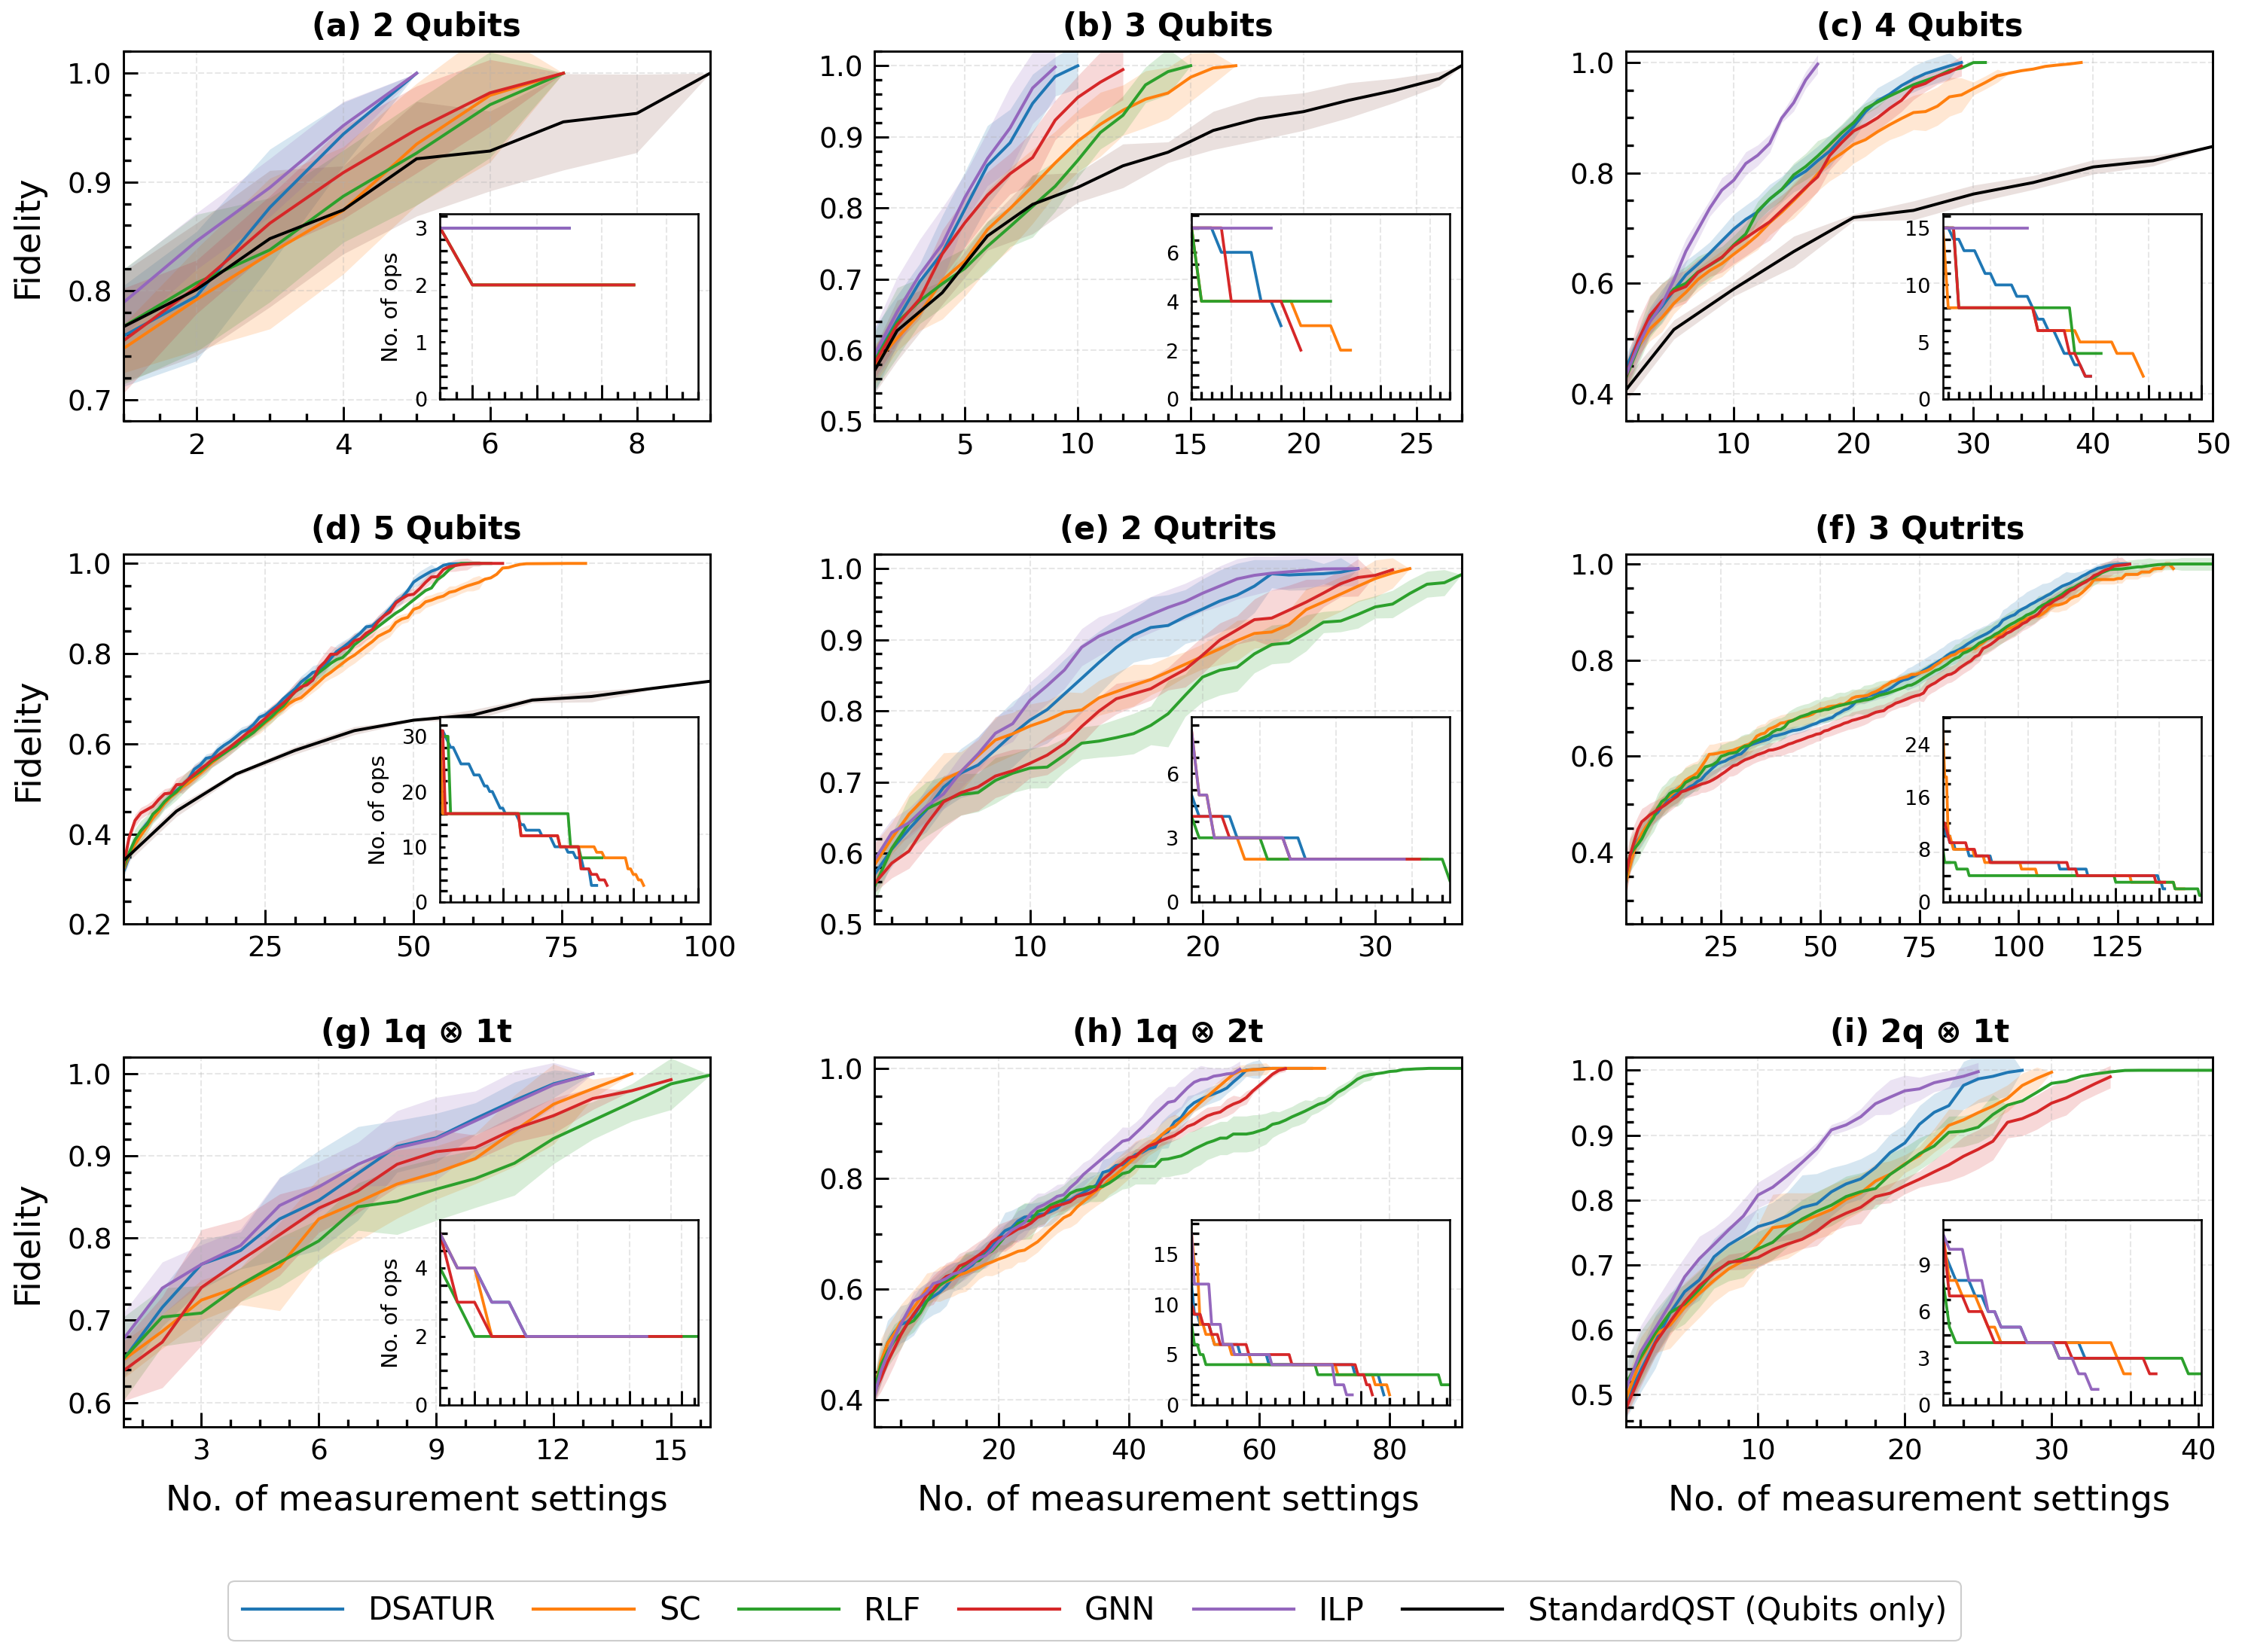

In [13]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 17,
    "axes.titlesize": 20,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20,
    "axes.linewidth": 1.6,
    "xtick.major.width": 1.4,
    "ytick.major.width": 1.4,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

candidates = [
    "QST_scheduling.csv",
    "standard_QST_mixed.csv",
    "standard_QST.csv",
    *sorted(glob.glob("*GRID2x3*FIXEDMARKERS*DSATUR*SC*.csv")),
    *sorted(glob.glob("*standard*QST*.csv")),
    *sorted(glob.glob("*Standard*QST*.csv")),
]

seen = set()
candidates_unique = []
for p in candidates:
    if p not in seen:
        candidates_unique.append(p)
        seen.add(p)

csvs = [p for p in candidates_unique if os.path.exists(p)]

if not csvs:
    raise FileNotFoundError(
        "No CSVs found. Place QST_scheduling.csv and standard_QST_mixed.csv next to this notebook."
    )

dfs = []
for p in csvs:
    try:
        dfp = pd.read_csv(p)
        if {"method", "system", "K", "fidelity_mean"}.issubset(dfp.columns):
            dfp["__source__"] = os.path.basename(p)
            dfs.append(dfp)
    except Exception as e:
        print(f"[WARN] Could not read {p}: {e}")

if not dfs:
    raise RuntimeError("No readable CSV with required columns: method, system, K, fidelity_mean.")

df = pd.concat(dfs, ignore_index=True, sort=False)

def norm_text(x):
    return str(x).strip()

def norm_system(s):
    s = norm_text(s).lower().replace(" ", "")
    if s in ("q", "qubit", "qubits"):
        return "qubit"
    if s in ("t", "qutrit", "qutrits"):
        return "qutrit"
    if "hybrid" in s:
        return "hybrid"
    return norm_text(s)

for c in ["method", "system", "hybrid_label"]:
    if c in df.columns:
        df[c] = df[c].map(norm_text)

for c in ["N", "K", "fidelity_mean", "fidelity_std", "setting_size", "n_qubits", "n_qutrits"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "system" in df.columns:
    df["system"] = df["system"].map(norm_system)

def normalize_hybrid_label(row):
    lab = str(row.get("hybrid_label", "")).strip()
    nq  = row.get("n_qubits", np.nan)
    nt  = row.get("n_qutrits", np.nan)

    s = lab.lower().replace(" ", "").replace("_", "")
    s = s.replace("tensor", "⊗").replace("*", "⊗").replace("x", "⊗")

    m = re.search(r"(\d+)\s*q.*?⊗.*?(\d+)\s*t", s)
    if m:
        return f"{int(m.group(1))}q ⊗ {int(m.group(2))}t"

    m2 = re.search(r"(\d+)\s*q.*?(\d+)\s*t", s)
    if m2:
        return f"{int(m2.group(1))}q ⊗ {int(m2.group(2))}t"

    if pd.notna(nq) and pd.notna(nt):
        return f"{int(nq)}q ⊗ {int(nt)}t"

    return lab

if "system" in df.columns:
    mask_h = df["system"] == "hybrid"
    if mask_h.any():
        df.loc[mask_h, "hybrid_label"] = df[mask_h].apply(normalize_hybrid_label, axis=1)

required = {"method", "system", "K", "fidelity_mean"}
df = df.dropna(subset=list(required))

preferred = ["DSATUR", "SC", "RLF", "GNN", "ILP"]
present   = [m for m in preferred if m in set(df["method"].dropna().unique())]
extras    = [m for m in df["method"].dropna().unique() if m not in present]
methods_order = present + list(dict.fromkeys(extras))

baseline_aliases = ["SOTA", "SoTA", "Standard", "StdQST", "StandardQST", "Baseline", "Ref", "Reference"]

def is_baseline_method(name: str) -> bool:
    low = name.lower()
    return any(b.lower() in low for b in baseline_aliases)

base_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [f"C{i}" for i in range(12)])
method_color = {m: base_colors[i % len(base_colors)] for i, m in enumerate(methods_order)}

LEGEND_LABEL_OVERRIDE = {
    "StandardQST": "StandardQST (Qubits only)"
}

LINE_COLOR_OVERRIDE = {
    "StandardQST": "k",
}

PANEL_YLIMS = {
    ("qubit", 2): (0.68, 1.02),
    ("qubit", 3): (0.50, 1.02),
    ("qubit", 4): (0.35, 1.02),
    ("qubit", 5): (0.20, 1.02),
    ("qutrit", 2): (0.50, 1.02),
    ("qutrit", 3): (0.25, 1.02),
    ("hybrid", "1q ⊗ 1t"): (0.57, 1.02),
    ("hybrid", "1q ⊗ 2t"): (0.35, 1.02),
    ("hybrid", "2q ⊗ 1t"): (0.45, 1.02),
}

def set_even_integer_ticks(ax, xvals, nticks=5):
    xvals = np.asarray(xvals, dtype=int)
    if xvals.size == 0:
        return

    xmin, xmax = int(np.min(xvals)), int(np.max(xvals))

    if xmin == xmax:
        ax.set_xlim(xmin, xmax)
        ax.set_xticks([xmin])
        ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
        return

    span = xmax - xmin
    nice_steps = np.array([1, 2, 3, 5, 10, 20, 25, 50, 100])
    rough = max(1, int(round(span / max(1, nticks - 1))))
    step = int(nice_steps[np.argmin(np.abs(nice_steps - rough))])

    t0 = int(np.ceil(xmin / step) * step)
    t1 = int(np.floor(xmax / step) * step)

    if t1 < t0:
        t0 = xmin
        t1 = xmax
        step = max(1, span)

    ticks = list(range(t0, t1 + 1, step))

    ax.set_xlim(xmin, xmax)
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))

def build_series(df_panel):
    series, allK = [], []

    for m in methods_order:
        sub = df_panel[df_panel["method"] == m].copy()
        if sub.empty:
            continue

        sub = sub.dropna(subset=["K", "fidelity_mean"])

        agg = sub.groupby(["K"], as_index=False).agg(
            fidelity_mean=("fidelity_mean", "mean"),
            fidelity_std=("fidelity_std", lambda s: float(np.sqrt(np.nanmean(np.square(s)))))
        )

        if "setting_size" in sub.columns:
            ss = sub.groupby("K")["setting_size"].agg(
                lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan
            )
            agg = agg.merge(ss.reset_index(), on="K", how="left")

        agg = agg.sort_values("K")

        K  = agg["K"].to_numpy(int)
        mu = agg["fidelity_mean"].to_numpy(float)
        sd = agg["fidelity_std"].to_numpy(float)
        sd = np.nan_to_num(sd, nan=0.0)

        sz = None
        if "setting_size" in agg.columns:
            sz = agg["setting_size"].to_numpy()
            if np.all(np.isnan(sz)):
                sz = None
            else:
                try:
                    sz = sz.astype(int)
                except:
                    pass

        series.append((m, K, mu, sd, sz))
        allK.append(K)

    Ks = np.unique(np.concatenate(allK)) if allK else np.array([], dtype=int)
    return series, Ks

INSET_BOX_DEFAULT = (0.54, 0.06, 0.44, 0.50)
INSET_BOX_QUTRIT  = (0.54, 0.06, 0.44, 0.50)

INSET_LINEWIDTH = 1.8
INSET_TICKSIZE  = 13
INSET_LABELSIZE = 14
INSET_SPINE_W   = 1.3

def add_inset(ax_main, inset_triplets, inset_qutrit=False, label_y=False, inset_box=None):
    if inset_box is None:
        inset_box = INSET_BOX_QUTRIT if inset_qutrit else INSET_BOX_DEFAULT

    ax_ins = ax_main.inset_axes(inset_box, facecolor="white", zorder=5)

    max_y = 1

    for ln, Kvals, sizes in inset_triplets:
        if sizes is None or len(sizes) == 0:
            continue

        if Kvals is None or len(Kvals) != len(sizes):
            x = np.arange(1, len(sizes) + 1, dtype=int)
        else:
            x = np.asarray(Kvals, dtype=float)

        ax_ins.plot(x, sizes, linewidth=INSET_LINEWIDTH, color=ln.get_color(), alpha=1.0)

        if len(sizes):
            max_y = max(max_y, int(np.max(sizes)))

    xmin, xmax = ax_main.get_xlim()
    ax_ins.set_xlim(xmin, xmax)

    main_ticks = ax_main.get_xticks()
    ax_ins.set_xticks(main_ticks)

    ax_ins.grid(True, axis="x", which="major", alpha=0.30, linestyle="--", linewidth=1.0)

    ax_ins.set_xticklabels([])
    ax_ins.tick_params(axis="x", which="both", labelbottom=False)

    ax_ins.set_ylim(0, max_y * 1.08 if max_y > 0 else 1)
    ax_ins.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
    ax_ins.tick_params(axis="y", which="major", labelsize=INSET_TICKSIZE, length=3.4, pad=8)

    if label_y:
        ax_ins.set_ylabel("No. of ops", fontsize=INSET_LABELSIZE, labelpad=8)

    for sp in ax_ins.spines.values():
        sp.set_linewidth(INSET_SPINE_W)
        sp.set_alpha(0.95)

def plot_panel(
    ax,
    df_panel,
    title,
    panel_key,
    add_ylabel=False,
    add_xlabel=False,
    inset_qutrit=False,
    inset_label_y=False
):
    series, Ks = build_series(df_panel)

    if not series:
        ax.set_title(title, fontsize=20, fontweight="bold", pad=10)
        ax.set_xlim(0, 1)
        ymin, ymax = PANEL_YLIMS.get(panel_key, (0.80, 1.02))
        ax.set_ylim(ymin, ymax)
        ax.set_xticks([])
        ax.set_yticks([])

        for sp in ax.spines.values():
            sp.set_linewidth(1.4)

        return []

    line_handles = []

    for (m, K, mu, sd, sz) in series:
        band_col = method_color.get(m, None)
        line_col = LINE_COLOR_OVERRIDE.get(m, band_col)

        lo = mu - sd
        hi = mu + sd

        lo, hi = np.minimum(lo, hi), np.maximum(lo, hi)
        lo = np.clip(lo, 0.0, 1.05)
        hi = np.clip(hi, 0.0, 1.05)

        ax.fill_between(K, lo, hi, color=band_col, alpha=0.18, linewidth=0, zorder=1)

        (ln,) = ax.plot(K, mu, linewidth=1.9, color=line_col, label=m, zorder=2)
        line_handles.append((ln, K, sz))

    ymin, ymax = PANEL_YLIMS.get(panel_key, (0.80, 1.02))
    ax.set_ylim(ymin, ymax)

    if Ks.size:
        set_even_integer_ticks(ax, Ks, nticks=5)

    ax.grid(True, alpha=0.30, linestyle="--", linewidth=1.0)

    if add_ylabel:
        ax.set_ylabel("Fidelity", labelpad=14)

    if add_xlabel:
        ax.set_xlabel("No. of measurement settings", labelpad=12)

    ax.set_title(title, fontsize=20, fontweight="bold", pad=10)

    for sp in ax.spines.values():
        sp.set_linewidth(1.4)

    inset_triplets = []

    for (ln, K, sz) in line_handles:
        m = ln.get_label() or "unknown"
        if is_baseline_method(m):
            continue
        inset_triplets.append((ln, K, sz))

    add_inset(ax, inset_triplets, inset_qutrit=inset_qutrit, label_y=inset_label_y)

    ax.tick_params(axis="x", labelsize=18, pad=7)
    ax.tick_params(axis="y", labelsize=18, pad=7)

    for lbl in ax.get_xticklabels():
        lbl.set_ha("center")

    return line_handles

qubit_df   = df[df["system"] == "qubit"].copy()
qutrit_df  = df[df["system"] == "qutrit"].copy()
hybrid_df  = df[df["system"] == "hybrid"].copy()

def sel_qubits(n):
    return qubit_df[qubit_df["N"] == n]

def sel_qutrits(n):
    return qutrit_df[qutrit_df["N"] == n]

def sel_hybrid(lbl):
    return hybrid_df[hybrid_df["hybrid_label"] == lbl]

layout = [
    ("qubit", 2),
    ("qubit", 3),
    ("qubit", 4),
    ("qubit", 5),
    ("qutrit", 2),
    ("qutrit", 3),
    ("hybrid", "1q ⊗ 1t"),
    ("hybrid", "1q ⊗ 2t"),
    ("hybrid", "2q ⊗ 1t"),
]

letters = list("abcdefghi")
panels = []

for i, (kind, key) in enumerate(layout):
    if kind == "qubit":
        sub = sel_qubits(key)
        base_title = f"{key} Qubits"
    elif kind == "qutrit":
        sub = sel_qutrits(key)
        base_title = f"{key} Qutrits"
    else:
        sub = sel_hybrid(key)
        base_title = key

    title = f"({letters[i]}) {base_title}"
    panels.append((kind, key, sub, title))

fig_w, fig_h = 20.0, 14.5
fig, axes = plt.subplots(3, 3, figsize=(fig_w, fig_h), squeeze=False)

global_methods_present = set()

for idx, ax in enumerate(axes.flat):
    kind, key, sub, title = panels[idx]
    r, c = divmod(idx, 3)

    show_xlabel   = (r == 2)
    show_ylabel   = (c == 0)
    inset_qutrit  = (r == 1 and c in (1, 2))
    inset_label_y = (c == 0)

    if sub.empty:
        ax.set_title(title, fontsize=20, fontweight="bold", pad=10)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=16)
        ax.set_xticks([])
        ax.set_yticks([])

        ymin, ymax = PANEL_YLIMS.get((kind, key), (0.80, 1.02))
        ax.set_ylim(ymin, ymax)

        for sp in ax.spines.values():
            sp.set_linewidth(1.4)
    else:
        plot_panel(
            ax,
            sub,
            title,
            (kind, key),
            add_ylabel=show_ylabel,
            add_xlabel=show_xlabel,
            inset_qutrit=inset_qutrit,
            inset_label_y=inset_label_y
        )

        for m in sub["method"].dropna().unique():
            global_methods_present.add(m)

legend_labels = [m for m in methods_order if m in global_methods_present]
legend_handles = []
legend_texts = []

for m in legend_labels:
    leg_col = LINE_COLOR_OVERRIDE.get(m, method_color.get(m))
    legend_handles.append(Line2D([0], [0], color=leg_col, linewidth=2.0))
    legend_texts.append(LEGEND_LABEL_OVERRIDE.get(m, m))

ncol = min(6, max(1, len(legend_labels)))

fig.legend(
    handles=legend_handles,
    labels=legend_texts,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=ncol,
    frameon=True,
    fancybox=True,
    framealpha=0.98,
    borderpad=0.45,
    labelspacing=0.50,
    handlelength=3.2,
    columnspacing=1.2,
    prop={"size": 20}
)

plt.tight_layout()

plt.subplots_adjust(
    left=0.07,
    right=0.995,
    top=0.97,
    bottom=0.13,
    wspace=0.28,
    hspace=0.36
)

display(fig)
plt.close(fig)